Date du jour: 2026-02-10
Téléchargement FRED – US_HY_OAS (BAMLH0A0HYM2)...
Téléchargement FRED – EU_HY_OAS (BAMLHE00EHYIOAS)...
Téléchargement FRED – US_BB_HY_OAS (BAMLH0A1HYBB)...
Téléchargement FRED – US_IG_OAS (BAMLC0A0CM)...
Téléchargement FRED – US_2Y (DGS2)...
Téléchargement FRED – US_5Y (DGS5)...
Téléchargement FRED – US_10Y (DGS10)...
Téléchargement FRED – US_2s10s (T10Y2Y)...
Téléchargement FRED – US_10Y_Breakeven (T10YIE)...
Téléchargement FRED – EUR_ESTR (ECBESTRVOLWGTTRMDMNRT)...

=== SYNTHÈSE FRED (valeur actuelle + moyenne 10 ans) ===


,source,name,label,asof,current,mean_10y,unit
9,FRED,EUR_ESTR,Euro Short-Term Rate (€STR),2026-02-09,1.93,1.2489,%
1,FRED,EU_HY_OAS,ICE BofA Euro High Yield Index OAS,2026-02-06,261.00,385.0865,bps
10,FRED,HY_IG_OAS_SPREAD,US HY – IG OAS spread,2026-02-06,211.00,286.1592,bps
6,FRED,US_10Y,US 10Y Treasury yield,2026-02-06,4.22,2.7161,%
8,FRED,US_10Y_Breakeven,US 10Y breakeven inflation,2026-02-09,2.35,2.0607,%
4,FRED,US_2Y,US 2Y Treasury yield,2026-02-06,3.50,2.3372,%
7,FRED,US_2s10s,US 10Y–2Y Treasury spread,2026-02-09,74.00,37.8768,bps
5,FRED,US_5Y,US 5Y Treasury yield,2026-02-06,3.76,2.4648,%
2,FRED,US_BB_HY_OAS,ICE BofA BB US High Yield Index OAS,2026-02-06,171.00,263.1354,bps
0,FRED,US_HY_OAS,ICE BofA US High Yield Index OAS,2026-02-06,287.00,406.2242,bps



OK – fichiers macro écrits: macro_fred_timeseries.csv, macro_summary_fred.csv

=== PORTEFEUILLE (6 lignes) — mapping forcé ===


,ticker,bloc,etf,isin,weight,role
0,CBUE.DE,Core UST belly (EUR-hedged),iShares USD Treasury 3-7 EUR Hedged,IE00BGPP6473,0.23,"Carry/roll-down 3–7 ans, USD neutralisé"
1,SXRP.DE,Core EUR gov belly,iShares € Govt Bond 3-7 (Acc),IE00B3VTML14,0.23,Même logique en EUR : cœur DV01
2,EUN6.DE,Cash / Bills,iShares € Govt Bond 0-1,IE00B3FH7618,0.25,Dry powder + amortisseur vol + capacité d’acha...
3,IBCQ.DE,IG corporate global (EUR-hedged),iShares Global Corp Bond EUR Hedged,IE00B9M6SJ31,0.12,"Spread IG diversifié, hedgé EUR"
4,IMBE.AS,Agency MBS (EUR-hedged),iShares US MBS EUR Hedged (Acc),IE00BKP5L409,0.10,"Spread différent du corporate, duration modérée"
5,XGIN.DE,Inflation-linked (EUR-hedged),Xtrackers Global ILB EUR Hedged,LU0290357929,0.07,Hedge inflation/term premium


/Users/zynay/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:147: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
/Users/zynay/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()



=== QA données prix (Yahoo) ===


,ticker,status,first,last,obs
0,CBUE.DE,OK,2025-01-02,2026-02-10,289
1,SXRP.DE,OK,2025-01-02,2026-02-10,289
2,EUN6.DE,OK,2025-01-02,2026-02-10,289
3,IBCQ.DE,OK,2025-01-02,2026-02-10,289
4,IMBE.AS,OK,2025-01-02,2026-02-10,289
5,XGIN.DE,OK,2025-01-02,2026-02-10,289
6,AGGH.AS,OK,2025-01-02,2026-02-10,289



Fenêtre commune 2025 utilisée: 2025-01-02 -> 2025-12-31

=== SHARPE & STATS — ANNÉE 2025 (excess vs €STR) ===


,series,ann_return,ann_vol,sharpe_excess_vs_estr,max_drawdown
0,Portfolio (monthly rebalanced),0.034535,0.026235,0.713945,-0.014671
1,Benchmark AGGH,0.026015,0.032554,0.321263,-0.018815



Fenêtre commune 2026 utilisée: 2026-01-01 -> 2026-02-10


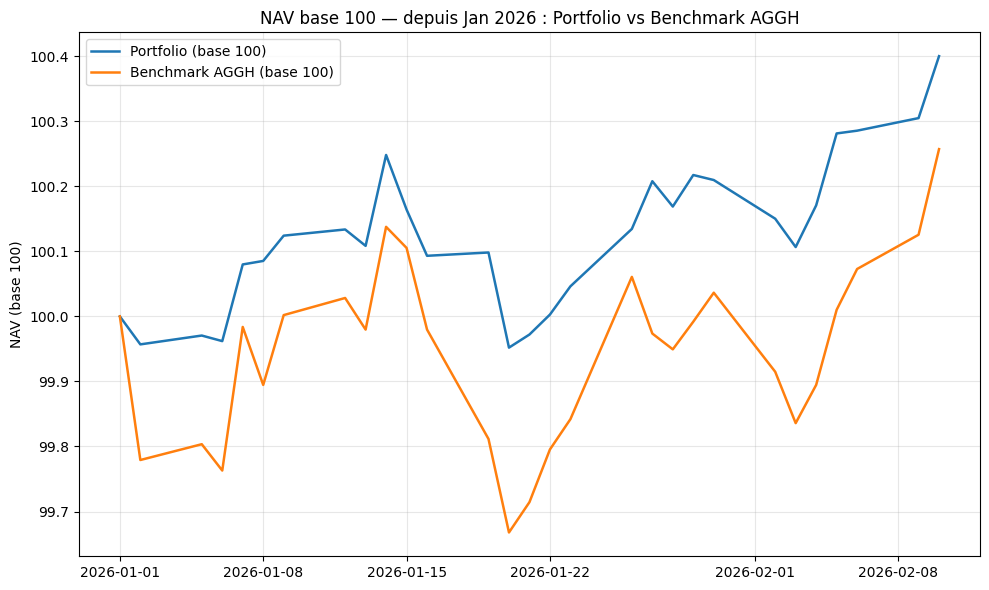


OK – exports écrits :
 - stats_2025_portfolio_vs_AGGH.csv
 - nav_2026_portfolio_vs_AGGH.csv


In [1]:
# =========================================================
# Fixed income Portfolio + BENCHMARK AGGH
# - Portefeuille: 6 ETFs 
# - Benchmark: AGGH uniquement (appelé "Benchmark AGGH")
# - Graph NAV base 100 depuis Jan 2026: Portfolio vs AGGH
# - Sharpe 2025 (excess vs €STR)
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Try to use Jupyter display if available
try:
    from IPython.display import display
    _HAS_DISPLAY = True
except Exception:
    _HAS_DISPLAY = False

# =========================================================
# 0) CONFIG
# =========================================================
FRED_API_KEY = "31692517396dd6b0c5bebdebc99e4990"

MACRO_START   = "2010-01-01"
YTD_2026_START = "2026-01-01"
Y2025_START   = "2025-01-01"
Y2025_END     = "2025-12-31"

TODAY = pd.Timestamp.today().normalize()
print(f"Date du jour: {TODAY.date()}")

# =========================================================
# 1) PORTFOLIO (6 lignes, mapping forcé)
# =========================================================
PORTFOLIO = [
    {
        "ticker": "CBUE.DE",
        "bloc": "Core UST belly (EUR-hedged)",
        "etf": "iShares USD Treasury 3-7 EUR Hedged",
        "isin": "IE00BGPP6473",
        "weight": 0.23,
        "role": "Carry/roll-down 3–7 ans, USD neutralisé",
    },
    {
        "ticker": "SXRP.DE",
        "bloc": "Core EUR gov belly",
        "etf": "iShares € Govt Bond 3-7 (Acc)",
        "isin": "IE00B3VTML14",
        "weight": 0.23,
        "role": "Même logique en EUR : cœur DV01",
    },
    {
        "ticker": "EUN6.DE",
        "bloc": "Cash / Bills",
        "etf": "iShares € Govt Bond 0-1",
        "isin": "IE00B3FH7618",
        "weight": 0.25,
        "role": "Dry powder + amortisseur vol + capacité d’achat sur widening",
    },
    {
        "ticker": "IBCQ.DE",
        "bloc": "IG corporate global (EUR-hedged)",
        "etf": "iShares Global Corp Bond EUR Hedged",
        "isin": "IE00B9M6SJ31",
        "weight": 0.12,
        "role": "Spread IG diversifié, hedgé EUR",
    },
    {
        "ticker": "IMBE.AS",
        "bloc": "Agency MBS (EUR-hedged)",
        "etf": "iShares US MBS EUR Hedged (Acc)",
        "isin": "IE00BKP5L409",
        "weight": 0.10,
        "role": "Spread différent du corporate, duration modérée",
    },
    {
        "ticker": "XGIN.DE",
        "bloc": "Inflation-linked (EUR-hedged)",
        "etf": "Xtrackers Global ILB EUR Hedged",
        "isin": "LU0290357929",
        "weight": 0.07,
        "role": "Hedge inflation/term premium",
    },
]

BENCHMARK = {"name": "Benchmark AGGH", "ticker": "AGGH.AS"}

# =========================================================
# 2) MACRO (FRED)
# =========================================================
FRED_SERIES = {
    "US_HY_OAS": {"fred_id": "BAMLH0A0HYM2", "label": "ICE BofA US High Yield Index OAS", "unit": "bps"},
    "EU_HY_OAS": {"fred_id": "BAMLHE00EHYIOAS", "label": "ICE BofA Euro High Yield Index OAS", "unit": "bps"},
    "US_BB_HY_OAS": {"fred_id": "BAMLH0A1HYBB", "label": "ICE BofA BB US High Yield Index OAS", "unit": "bps"},
    "US_IG_OAS": {"fred_id": "BAMLC0A0CM", "label": "ICE BofA US Corporate Index OAS", "unit": "bps"},
    "US_2Y": {"fred_id": "DGS2", "label": "US 2Y Treasury yield", "unit": "%"},
    "US_5Y": {"fred_id": "DGS5", "label": "US 5Y Treasury yield", "unit": "%"},
    "US_10Y": {"fred_id": "DGS10", "label": "US 10Y Treasury yield", "unit": "%"},
    "US_2s10s": {"fred_id": "T10Y2Y", "label": "US 10Y–2Y Treasury spread", "unit": "bps"},
    "US_10Y_Breakeven": {"fred_id": "T10YIE", "label": "US 10Y breakeven inflation", "unit": "%"},
    # Risk-free proxy EUR
    "EUR_ESTR": {"fred_id": "ECBESTRVOLWGTTRMDMNRT", "label": "Euro Short-Term Rate (€STR)", "unit": "%"},
}

# =========================================================
# 3) HELPERS (display / FRED / prices / portfolio math)
# =========================================================
def show_df(df: pd.DataFrame, title: str, round_map: dict | None = None):
    print("\n" + title)
    out = df.copy()
    if round_map:
        for col, dec in round_map.items():
            if col in out.columns:
                out[col] = pd.to_numeric(out[col], errors="coerce").round(dec)
    if _HAS_DISPLAY:
        display(out)
    else:
        with pd.option_context("display.width", 200, "display.max_columns", 60):
            print(out.to_string(index=False))

def get_fred_series(series_id: str, start: str) -> pd.Series:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    obs = r.json()["observations"]
    s = pd.Series({o["date"]: (float(o["value"]) if o["value"] != "." else np.nan) for o in obs})
    s.index = pd.to_datetime(s.index)
    return s.sort_index()

def fetch_fred_all(start=MACRO_START) -> pd.DataFrame:
    data = {}
    for k, meta in FRED_SERIES.items():
        print(f"Téléchargement FRED – {k} ({meta['fred_id']})...")
        data[k] = get_fred_series(meta["fred_id"], start).rename(k)
    return pd.concat(data.values(), axis=1)

def fred_summary_table(fred_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for k, meta in FRED_SERIES.items():
        s = fred_df[k].dropna()
        if s.empty:
            continue
        asof = s.index.max()
        cur = float(s.iloc[-1])
        s10 = s.loc[asof - pd.DateOffset(years=10):]
        m10 = float(s10.mean()) if not s10.empty else np.nan

        # Convert to bps if relevant series are in % terms on FRED
        if meta["unit"] == "bps":
            cur_disp = cur * 100
            m10_disp = m10 * 100
        else:
            cur_disp = cur
            m10_disp = m10

        rows.append({
            "source": "FRED",
            "name": k,
            "label": meta["label"],
            "asof": asof.date(),
            "current": cur_disp,
            "mean_10y": m10_disp,
            "unit": meta["unit"],
        })

    # Derived HY-IG OAS spread if possible
    if {"US_HY_OAS", "US_IG_OAS"}.issubset(fred_df.columns):
        spr = (fred_df["US_HY_OAS"] - fred_df["US_IG_OAS"]).dropna()
        if not spr.empty:
            asof = spr.index.max()
            s10 = spr.loc[asof - pd.DateOffset(years=10):]
            rows.append({
                "source": "FRED",
                "name": "HY_IG_OAS_SPREAD",
                "label": "US HY – IG OAS spread",
                "asof": asof.date(),
                "current": float(spr.iloc[-1]) * 100,
                "mean_10y": float(s10.mean()) * 100 if not s10.empty else np.nan,
                "unit": "bps",
            })

    return pd.DataFrame(rows).sort_values(["source", "name"])

def yf_adj_close(tickers, start, end=None) -> pd.DataFrame:
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        progress=False,
        auto_adjust=False,
        threads=True,
    )
    if data is None or len(data) == 0:
        return pd.DataFrame()

    # normalize tz
    if hasattr(data.index, "tz") and data.index.tz is not None:
        data.index = data.index.tz_convert(None)

    if isinstance(data.columns, pd.MultiIndex):
        if "Adj Close" in data.columns.get_level_values(0):
            px = data["Adj Close"].copy()
        elif "Close" in data.columns.get_level_values(0):
            px = data["Close"].copy()
        else:
            raise KeyError("Ni 'Adj Close' ni 'Close' trouvés (MultiIndex).")
    else:
        # single ticker shape
        if "Adj Close" in data.columns:
            px = data[["Adj Close"]].copy()
            px.columns = [tickers if isinstance(tickers, str) else str(tickers[0])]
        elif "Close" in data.columns:
            px = data[["Close"]].copy()
            px.columns = [tickers if isinstance(tickers, str) else str(tickers[0])]
        else:
            raise KeyError("Ni 'Adj Close' ni 'Close' trouvés (colonnes simples).")

    px = px.sort_index().dropna(how="all")
    px.columns = [str(c) for c in px.columns]
    return px

def align_business_days(px: pd.DataFrame) -> pd.DataFrame:
    px = px.sort_index()
    idx = pd.date_range(px.index.min(), px.index.max(), freq="B")
    return px.reindex(idx).ffill()

def qa_prices(px: pd.DataFrame, tickers: list[str]) -> pd.DataFrame:
    rows = []
    for t in tickers:
        if t not in px.columns:
            rows.append({"ticker": t, "status": "MISSING_COLUMN", "first": None, "last": None, "obs": 0})
            continue
        s = px[t].dropna()
        rows.append({
            "ticker": t,
            "status": "OK" if not s.empty else "EMPTY",
            "first": s.index.min().date() if not s.empty else None,
            "last":  s.index.max().date() if not s.empty else None,
            "obs": int(s.shape[0])
        })
    return pd.DataFrame(rows)

def common_window(px: pd.DataFrame, cols: list[str], start: str, end: str) -> pd.DataFrame:
    w = px.loc[pd.to_datetime(start):pd.to_datetime(end), cols].copy()
    w = w.dropna(axis=0, how="any")
    return w

def monthly_rebalanced_nav(px_assets: pd.DataFrame, weights: pd.Series, base: float = 100.0) -> pd.Series:
    """
    VRAI rebalancement mensuel (holdings fixes entre rebalances).
    - Au 1er jour ouvré de chaque mois, on remet les holdings aux poids cibles.
    """
    px = px_assets.dropna(axis=0, how="any").copy()
    if px.shape[0] < 3:
        return pd.Series(dtype=float, name="NAV_Portfolio")

    # rebalance dates = 1er jour ouvré par mois
    rebal_dates = px.groupby(px.index.to_period("M")).apply(lambda df: df.index[0]).tolist()
    rebal_dates = set(rebal_dates)

    w = weights.reindex(px.columns).astype(float)
    w = w / w.sum()

    nav = pd.Series(index=px.index, dtype=float, name="NAV_Portfolio")
    holdings = None

    for i, dt in enumerate(px.index):
        prices = px.loc[dt]

        if i == 0:
            # initial holdings
            holdings = (base * w) / prices
            nav.loc[dt] = float((holdings * prices).sum())
            continue

        # update NAV with current holdings
        nav.loc[dt] = float((holdings * prices).sum())

        # rebalance at close of dt (simple convention)
        if dt in rebal_dates:
            holdings = (nav.loc[dt] * w) / prices

    return nav

def nav_from_price(px: pd.Series, base: float = 100.0) -> pd.Series:
    s = px.dropna()
    if s.empty:
        return pd.Series(dtype=float)
    nav = (s / s.iloc[0]) * base
    nav.name = "NAV_Benchmark"
    return nav

def sharpe_excess_vs_estr(nav: pd.Series, estr_pct: pd.Series, daycount=360, ann_factor=252) -> float:
    r = nav.pct_change().dropna()
    rf = estr_pct.reindex(r.index).ffill() / 100.0 / daycount
    ex = r - rf
    mu = ex.mean() * ann_factor
    sig = ex.std(ddof=1) * np.sqrt(ann_factor)
    return float(mu / sig) if sig > 0 else np.nan

def perf_stats(nav: pd.Series) -> dict:
    r = nav.pct_change().dropna()
    ann_ret = (1 + r.mean())**252 - 1
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    mdd = (nav / nav.cummax() - 1).min()
    return {"ann_return": float(ann_ret), "ann_vol": float(ann_vol), "max_drawdown": float(mdd)}

# =========================================================
# 4) RUN — MACRO FRED (output lisible)
# =========================================================
fred_df = fetch_fred_all(MACRO_START)
fred_sum = fred_summary_table(fred_df)
show_df(
    fred_sum,
    title="=== SYNTHÈSE FRED (valeur actuelle + moyenne 10 ans) ===",
    round_map={"current": 4, "mean_10y": 4}
)

# Save macro
fred_df.to_csv("macro_fred_timeseries.csv", index_label="Date")
fred_sum.to_csv("macro_summary_fred.csv", index=False)
print("\nOK – fichiers macro écrits: macro_fred_timeseries.csv, macro_summary_fred.csv")

# €STR series for Sharpe
estr = fred_df["EUR_ESTR"].dropna()

# =========================================================
# 5) RUN — PRICES (portfolio + AGGH) + outputs lisibles
# =========================================================
pmap = pd.DataFrame(PORTFOLIO)[["ticker", "bloc", "etf", "isin", "weight", "role"]].copy()
if abs(pmap["weight"].sum() - 1.0) > 1e-9:
    raise ValueError(f"Somme des poids != 1.0 : {pmap['weight'].sum()}")

show_df(pmap, title="=== PORTEFEUILLE (6 lignes) — mapping forcé ===", round_map={"weight": 2})

tickers_assets = pmap["ticker"].tolist()
ticker_bench = BENCHMARK["ticker"]
all_tickers = tickers_assets + [ticker_bench]

px_all = yf_adj_close(all_tickers, start=Y2025_START)
if px_all.empty:
    raise RuntimeError("Aucune donnée Yahoo récupérée. Vérifie yfinance / tickers / réseau.")

px_all = align_business_days(px_all)

qa = qa_prices(px_all, all_tickers)
show_df(qa, title="=== QA données prix (Yahoo) ===")

# =========================================================
# 6) SHARPE 2025 — Portfolio (MONTHLY rebalanced) vs Benchmark AGGH
# =========================================================
px_2025 = common_window(px_all, all_tickers, Y2025_START, Y2025_END)
if px_2025.empty:
    raise RuntimeError("Fenêtre commune 2025 vide (au moins un ticker sans données 2025).")

common_start_2025 = px_2025.index.min().date()
common_end_2025 = px_2025.index.max().date()
print(f"\nFenêtre commune 2025 utilisée: {common_start_2025} -> {common_end_2025}")

weights = pmap.set_index("ticker")["weight"]

nav_port_2025 = monthly_rebalanced_nav(px_2025[tickers_assets], weights, base=100.0)
nav_bench_2025 = nav_from_price(px_2025[ticker_bench], base=100.0)
nav_bench_2025.name = "NAV_Benchmark_AGGH"

estr_2025 = estr.reindex(nav_port_2025.index).ffill()

stats_2025 = []
# Portfolio
s_port = perf_stats(nav_port_2025)
s_port["series"] = "Portfolio (monthly rebalanced)"
s_port["sharpe_excess_vs_estr"] = sharpe_excess_vs_estr(nav_port_2025, estr_2025)
stats_2025.append(s_port)

# Benchmark
s_b = perf_stats(nav_bench_2025)
s_b["series"] = "Benchmark AGGH"
s_b["sharpe_excess_vs_estr"] = sharpe_excess_vs_estr(nav_bench_2025, estr_2025)
stats_2025.append(s_b)

stats_2025_df = pd.DataFrame(stats_2025)[["series", "ann_return", "ann_vol", "sharpe_excess_vs_estr", "max_drawdown"]]
show_df(stats_2025_df, title="=== SHARPE & STATS — ANNÉE 2025 (excess vs €STR) ===",
        round_map={"ann_return": 6, "ann_vol": 6, "sharpe_excess_vs_estr": 6, "max_drawdown": 6})

stats_2025_df.to_csv("stats_2025_portfolio_vs_AGGH.csv", index=False)

# =========================================================
# 7) NAV GRAPH — depuis Jan 2026 (base 100): Portfolio vs AGGH
# =========================================================
px_2026 = common_window(px_all, all_tickers, YTD_2026_START, str(TODAY.date()))
if px_2026.empty:
    raise RuntimeError("Fenêtre commune 2026 vide (au moins un ticker sans données depuis Jan 2026).")

common_start_2026 = px_2026.index.min().date()
common_end_2026 = px_2026.index.max().date()
print(f"\nFenêtre commune 2026 utilisée: {common_start_2026} -> {common_end_2026}")

nav_port_2026 = monthly_rebalanced_nav(px_2026[tickers_assets], weights, base=100.0)
nav_bench_2026 = nav_from_price(px_2026[ticker_bench], base=100.0)
nav_bench_2026.name = "NAV_Benchmark_AGGH"

nav_plot = pd.concat([nav_port_2026.rename("Portfolio"), nav_bench_2026.rename("Benchmark AGGH")], axis=1).dropna()

plt.figure(figsize=(10, 6))
plt.plot(nav_plot.index, nav_plot["Portfolio"], label="Portfolio (base 100)", linewidth=1.8)
plt.plot(nav_plot.index, nav_plot["Benchmark AGGH"], label="Benchmark AGGH (base 100)", linewidth=1.8)
plt.title("NAV base 100 — depuis Jan 2026 : Portfolio vs Benchmark AGGH")
plt.ylabel("NAV (base 100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

nav_plot.to_csv("nav_2026_portfolio_vs_AGGH.csv", index_label="Date")

print("\nOK – exports écrits :")
print(" - stats_2025_portfolio_vs_AGGH.csv")
print(" - nav_2026_portfolio_vs_AGGH.csv")